In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/bhautikvekariya21/air-quality-dataset-indian-cities-2022-2025/aqi_india_38cols_knn_final.csv
/kaggle/input/datasets/bhautikvekariya21/air-quality-dataset-indian-cities-2022-2025/INDIA_AQI_COMPLETE_20251126.csv


In [2]:
!pip install pennylane --quiet
!pip install pennylane-lightning[gpu]
!pip install pennylane-qiskit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 936.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 85.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 924.6/924.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.2/73.2 MB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB

In [3]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

import torch
import torch.nn as nn 
import torch.optim as optim 
from torch.utils.data import DataLoader, TensorDataset

import pennylane as qml
from pennylane import numpy as pnp

In [4]:
df = pd.read_csv("/kaggle/input/datasets/bhautikvekariya21/air-quality-dataset-indian-cities-2022-2025/aqi_india_38cols_knn_final.csv")

In [5]:
df

,city,state,latitude,longitude,datetime,month,day_name,is_weekend,season,time_of_day,...,no2_ugm3,so2_ugm3,o3_ugm3,dust_ugm3,aod,us_aqi,aqi_category,pm25_category_india,festival_period,crop_burning_season
0,agartala,tripura,23.8315,91.2868,2022-08-05 00:00:00,8.0,friday,False,monsoon,night,...,21.8,2.7,32.0,0.0,0.14,289.0,Very Unhealthy,good,False,False
1,agartala,tripura,23.8315,91.2868,2022-08-05 01:00:00,8.0,friday,False,monsoon,night,...,18.5,3.0,33.0,0.0,0.14,289.0,Very Unhealthy,good,False,False
2,agartala,tripura,23.8315,91.2868,2022-08-05 02:00:00,8.0,friday,False,monsoon,night,...,15.1,3.3,34.0,0.0,0.15,54.0,Moderate,good,False,False
3,agartala,tripura,23.8315,91.2868,2022-08-05 03:00:00,8.0,friday,False,monsoon,night,...,14.1,3.3,32.0,0.0,0.15,54.0,Moderate,good,False,False
4,agartala,tripura,23.8315,91.2868,2022-08-05 04:00:00,8.0,friday,False,monsoon,night,...,13.9,3.2,30.0,0.0,0.14,54.0,Moderate,good,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
842155,visakhapatnam,andhra pradesh,17.6868,83.2185,2025-11-26 19:00:00,11.0,wednesday,False,post_monsoon,evening,...,18.1,38.5,155.0,4.0,1.02,172.0,Unhealthy,moderate,False,True
842156,visakhapatnam,andhra pradesh,17.6868,83.2185,2025-11-26 20:00:00,11.0,wednesday,False,post_monsoon,evening,...,17.4,34.9,152.0,4.0,0.98,172.0,Unhealthy,moderate,False,True
842157,visakhapatnam,andhra pradesh,17.6868,83.2185,2025-11-26 21:00:00,11.0,wednesday,False,post_monsoon,night_late,...,17.2,30.9,146.0,4.0,0.96,171.0,Unhealthy,moderate,False,True
842158,visakhapatnam,andhra pradesh,17.6868,83.2185,2025-11-26 22:00:00,11.0,wednesday,False,post_monsoon,night_late,...,17.1,26.7,138.0,3.0,0.94,170.0,Unhealthy,moderate,False,True


In [6]:
# 11 columns and 1 lakh rows select kiya
best_features = ['us_aqi','no2_ugm3', 'so2_ugm3','o3_ugm3','dust_ugm3','season','crop_burning_season','aod','latitude','longitude','is_weekend']

df = df[best_features].sample(n=100000, random_state=42)

In [7]:
df

,us_aqi,no2_ugm3,so2_ugm3,o3_ugm3,dust_ugm3,season,crop_burning_season,aod,latitude,longitude,is_weekend
160063,111.0,5.4,9.5,91.0,2.0,summer,False,0.63,20.2961,85.8245,False
541575,40.0,5.1,4.6,62.0,0.0,monsoon,False,0.24,22.5726,88.3639,True
322601,19.0,0.0,0.8,27.0,0.0,winter,False,0.05,28.4595,77.0266,False
794503,24.0,6.7,3.2,46.0,0.0,post_monsoon,True,0.43,8.5241,76.9366,False
483702,78.0,22.6,8.8,37.0,32.0,post_monsoon,True,0.25,26.9124,75.7873,False
...,...,...,...,...,...,...,...,...,...,...,...
285692,289.0,60.7,23.9,62.0,641.0,summer,False,0.98,28.6139,77.2090,False
311977,112.0,21.6,4.1,42.0,0.0,winter,False,0.26,27.3389,88.6065,False
205632,65.0,9.4,6.1,115.0,1.0,post_monsoon,True,0.74,13.0827,80.2707,False
722566,68.0,17.3,11.5,42.0,0.0,monsoon,False,0.62,23.3441,85.3096,True


In [8]:
df.describe()

,us_aqi,no2_ugm3,so2_ugm3,o3_ugm3,dust_ugm3,aod,latitude,longitude
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,94.639983,16.042735,13.402491,80.003190,19.746080,0.463629,23.127662,82.775840
std,47.225174,19.931377,18.931303,44.758579,72.174869,0.299839,5.538451,6.933717
min,19.000000,0.000000,0.200000,0.000000,0.000000,0.050000,8.524100,72.571400
25%,59.000000,3.700000,2.800000,46.000000,0.000000,0.240000,20.296100,77.173400
50%,84.000000,9.100000,6.800000,72.000000,2.000000,0.400000,23.831500,80.946200
75%,128.000000,19.900000,15.700000,108.000000,11.000000,0.620000,26.912400,88.606500
max,289.000000,122.100000,134.200000,228.000000,714.000000,1.700000,31.104800,94.108600


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 160063 to 162120
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   us_aqi               100000 non-null  float64
 1   no2_ugm3             100000 non-null  float64
 2   so2_ugm3             100000 non-null  float64
 3   o3_ugm3              100000 non-null  float64
 4   dust_ugm3            100000 non-null  float64
 5   season               100000 non-null  object 
 6   crop_burning_season  100000 non-null  bool   
 7   aod                  100000 non-null  float64
 8   latitude             100000 non-null  float64
 9   longitude            100000 non-null  float64
 10  is_weekend           100000 non-null  bool   
dtypes: bool(2), float64(8), object(1)
memory usage: 7.8+ MB


In [10]:
df.isnull().sum()

us_aqi                 0
no2_ugm3               0
so2_ugm3               0
o3_ugm3                0
dust_ugm3              0
season                 0
crop_burning_season    0
aod                    0
latitude               0
longitude              0
is_weekend             0
dtype: int64

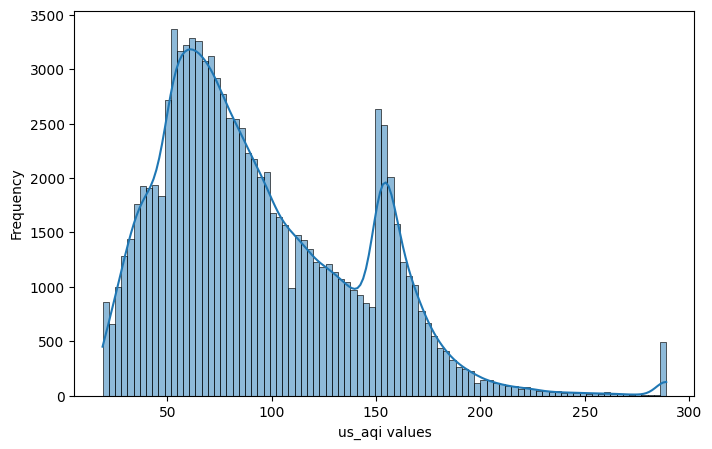

In [11]:
#df.plot.scatter(x='o3_ugm3', y='us_aqi', alpha=0.5)

import seaborn as sns
plt.figure(figsize=(8,5))
sns.histplot(df['us_aqi'],kde=True)
plt.xlabel('us_aqi values')
plt.ylabel('Frequency')
plt.show()

In [12]:

# df_encoded = df_subset.reset_index(drop=True)         # index ko htaya

df_encoded = pd.get_dummies(df, columns=['season'], drop_first=True)     # season se 3 columns bnaya

# one hot encoding
df_encoded[['crop_burning_season','is_weekend','season_post_monsoon','season_summer','season_winter']] = df_encoded[['crop_burning_season','is_weekend','season_post_monsoon','season_summer','season_winter']].astype(int)
df_encoded

,us_aqi,no2_ugm3,so2_ugm3,o3_ugm3,dust_ugm3,crop_burning_season,aod,latitude,longitude,is_weekend,season_post_monsoon,season_summer,season_winter
160063,111.0,5.4,9.5,91.0,2.0,0,0.63,20.2961,85.8245,0,0,1,0
541575,40.0,5.1,4.6,62.0,0.0,0,0.24,22.5726,88.3639,1,0,0,0
322601,19.0,0.0,0.8,27.0,0.0,0,0.05,28.4595,77.0266,0,0,0,1
794503,24.0,6.7,3.2,46.0,0.0,1,0.43,8.5241,76.9366,0,1,0,0
483702,78.0,22.6,8.8,37.0,32.0,1,0.25,26.9124,75.7873,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
285692,289.0,60.7,23.9,62.0,641.0,0,0.98,28.6139,77.2090,0,0,1,0
311977,112.0,21.6,4.1,42.0,0.0,0,0.26,27.3389,88.6065,0,0,0,1
205632,65.0,9.4,6.1,115.0,1.0,1,0.74,13.0827,80.2707,0,1,0,0
722566,68.0,17.3,11.5,42.0,0.0,0,0.62,23.3441,85.3096,1,0,0,0


In [13]:
X = df_encoded.drop('us_aqi', axis=1)
y = df_encoded['us_aqi']

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)


In [14]:
#Standard Scaling (Features ko mean=0, std=1 me scale karna Quantum ke liye zaroori hai)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
# pytorch tensor me convert 
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

# target 
y_train_tensor = torch.log1p(torch.tensor(y_train.values, dtype=torch.float32).view(-1,1))
y_test_tensor = torch.log1p(torch.tensor(y_test.values, dtype=torch.float32).view(-1,1))

In [16]:
print("preprocessing complete")
print("X_train tensor shape:", X_train_tensor.shape)
print("y_train tensor shape:", y_train_tensor.shape)

preprocessing complete
X_train tensor shape: torch.Size([80000, 12])
y_train tensor shape: torch.Size([80000, 1])


QUANTUM codes

In [17]:
n_qubits = 7
dev = qml.device("lightning.qubit", wires=n_qubits)
@qml.qnode(dev, interface="torch", diff_method="adjoint")

def q_ckt(inputs,weights):
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    qml.BasicEntanglerLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

class HybridModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.clayer_in = nn.Sequential(
            nn.Linear(12,32),
            nn.ReLU(),
            nn.Linear(32,7),    # 12 se waps 7 
            nn.Tanh()    # Tanh values [-1,1] for quantum angleEmbedding
            
        )
        self.q_weights = nn.Parameter(torch.randn(3, 7))
        self.clayer_out = nn.Sequential(
            nn.Linear(7,16),
            nn.ReLU(),
            nn.Linear(16,1)   # final single aqi prediction
            
        )

    def forward(self, x):
        # Data flows: Classical Input -> Relu -> Tanh
        x = self.clayer_in(x)
        q_out = q_ckt(x, self.q_weights)

        if isinstance(q_out, (tuple, list)):
            x = torch.stack([tensor for tensor in q_out], dim=1)
        else:
            x = q_out
        x = x.to(torch.float32)
        
        x = self.clayer_out(x)   # final prediction
        return x


# ------Training Loop-------
model = HybridModel()
loss_fn = nn.SmoothL1Loss()    # hubber loss
optimizer = optim.Adam(model.parameters(), lr=0.002)

dataloader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=256, shuffle=True)
val_dataloader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=256, shuffle=False)

from tqdm import tqdm
# ------Execution------
epochs = 20
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    progress = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}")
    for batch_x, batch_y in progress:
        optimizer.zero_grad()
        pred = model(batch_x)
        loss = loss_fn(pred, batch_y)
        loss.backward()
        optimizer.step()
        train_loss = train_loss + loss.item()

        progress.set_postfix({'loss': f"{loss.item():.4f}"})

    avg_train_loss = train_loss / len(dataloader)

    # ----- Validation -----
    model.eval()
    val_loss = 0.0
    real_aqi_error = 0.0
    
    with torch.no_grad():
        for val_x, val_y in val_dataloader:
            val_pred = model(val_x)
            v_loss = loss_fn(val_pred, val_y)
            val_loss += v_loss.item()

            real_pred = torch.expm1(val_pred)    # inverse of log fn.
            real_actual = torch.expm1(val_y)
            real_aqi_error += torch.abs(real_pred - real_actual).mean().item()   # MAE

    avg_val_loss = val_loss / len(val_dataloader)
    avg_real_error = real_aqi_error / len(val_dataloader)

    print(f"Epoch [{epoch+1}/{epochs}] | Log Train Loss: {avg_train_loss:.4f} | Log Val Loss:{avg_val_loss:.4f} | Real AQI error: +-{avg_real_error:.2f} points")

print("Training Successfully Completed.")

Epoch 1/20: 100%|██████████| 313/313 [07:56<00:00,  1.52s/it, loss=0.0411]


Epoch [1/20] | Log Train Loss: 1.1834 | Log Val Loss:0.0316 | Real AQI error: +-17.64 points


Epoch 2/20: 100%|██████████| 313/313 [07:53<00:00,  1.51s/it, loss=0.0343]


Epoch [2/20] | Log Train Loss: 0.0298 | Log Val Loss:0.0288 | Real AQI error: +-16.62 points


Epoch 3/20: 100%|██████████| 313/313 [07:51<00:00,  1.51s/it, loss=0.0300]


...

Epoch [18/20] | Log Train Loss: 0.0255 | Log Val Loss:0.0254 | Real AQI error: +-15.53 points


Epoch 19/20: 100%|██████████| 313/313 [07:51<00:00,  1.51s/it, loss=0.0248]


Epoch [19/20] | Log Train Loss: 0.0253 | Log Val Loss:0.0254 | Real AQI error: +-15.44 points


Epoch 20/20: 100%|██████████| 313/313 [07:45<00:00,  1.49s/it, loss=0.0202]


Epoch [20/20] | Log Train Loss: 0.0253 | Log Val Loss:0.0264 | Real AQI error: +-15.79 points
Training Successfully Completed.


In [18]:

# Model state dictionary ko save karna
torch.save(model.state_dict(), 'aqi_qml_model.pth')
print("Model successfully save ho gaya hai!")

Model successfully save ho gaya hai!
